(1460, 81)


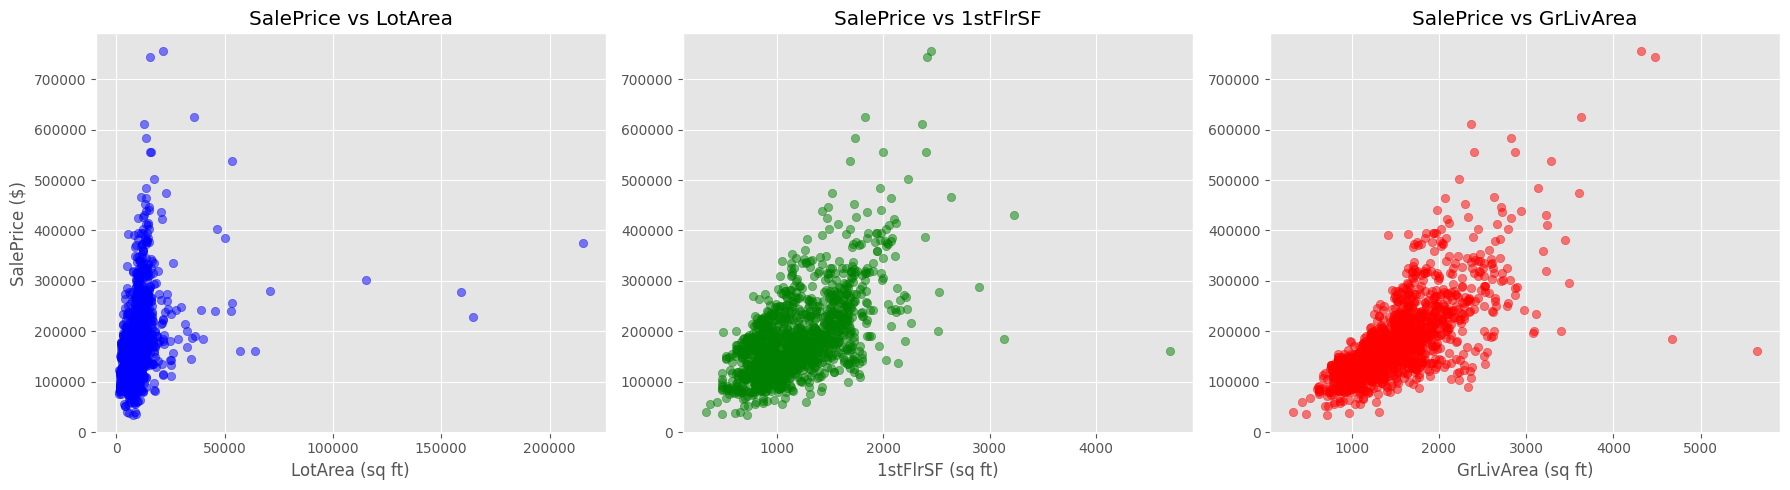

Training Vanilla Tree (max_depth=5)...
Vanilla Tree - R2: 0.6371, RMSE: 52762.48

Tuning max_depth (1 to 15 to save computation time)...


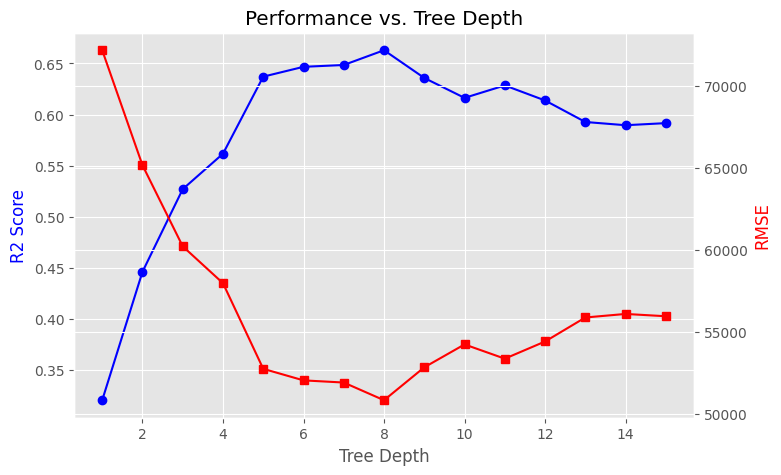


Tuning min_samples_split (2 to 10)...


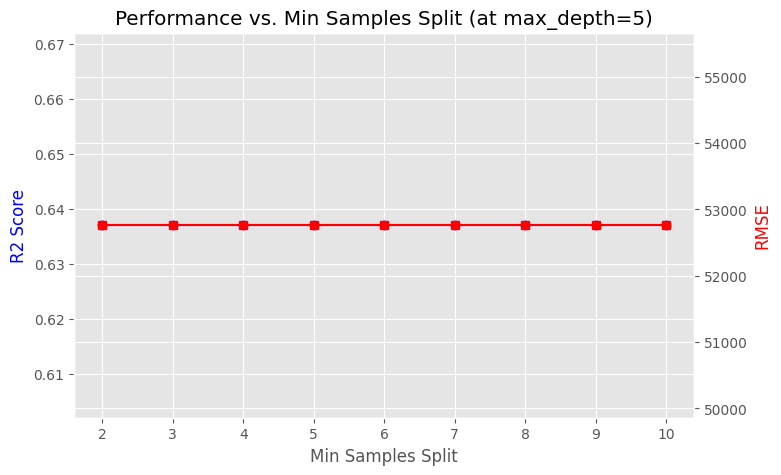


Training Sklearn DecisionTreeRegressor...
Sklearn Tree - R2: 0.6291, RMSE: 53341.07


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')
# %matplotlib inline # Uncomment if running in an actual Jupyter Notebook

# ---------------------------------------------------------
# Imports & Dataset Loading
# ---------------------------------------------------------
# Load dataset
data = pd.read_csv('ames.csv')
print(data.shape)
data.head()

# ---------------------------------------------------------
# Feature Selection
# ---------------------------------------------------------
# using 3 predictive continuous features: LotArea, 1stFlrSF, GrLivArea
# Target: SalePrice
features = data[['LotArea', '1stFlrSF', 'GrLivArea']].values
target = data['SalePrice'].values

# ---------------------------------------------------------
# Feature–Target Visualization
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(data['LotArea'], data['SalePrice'], alpha=0.5, color='blue')
axes[0].set_title('SalePrice vs LotArea')
axes[0].set_xlabel('LotArea (sq ft)')
axes[0].set_ylabel('SalePrice ($)')

axes[1].scatter(data['1stFlrSF'], data['SalePrice'], alpha=0.5, color='green')
axes[1].set_title('SalePrice vs 1stFlrSF')
axes[1].set_xlabel('1stFlrSF (sq ft)')

axes[2].scatter(data['GrLivArea'], data['SalePrice'], alpha=0.5, color='red')
axes[2].set_title('SalePrice vs GrLivArea')
axes[2].set_xlabel('GrLivArea (sq ft)')

plt.tight_layout()
plt.show()
# Comment: GrLivArea and 1stFlrSF show a clear positive linear correlation with SalePrice.
# LotArea shows a heavy concentration of data points at lower values with several high-leverage outliers.

# ---------------------------------------------------------
# Train–Test Split
# ---------------------------------------------------------
from sklearn.model_selection import train_test_split

# Use 80/20 split with random_state=42
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.20, random_state=42)

# ---------------------------------------------------------
# Evaluation Metrics
# ---------------------------------------------------------
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return 1.0
    return 1 - (ss_res / ss_tot)

def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def performance(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, rmse

# ---------------------------------------------------------
# Regression Impurity
# ---------------------------------------------------------
def regression_impurity(y):
    if len(y) == 0:
        return 0.0
    return np.mean((y - np.mean(y)) ** 2)

# ---------------------------------------------------------
# Best Split (Implement)
# ---------------------------------------------------------
def best_split(X, y):
    N, D = X.shape
    best_cost = np.inf
    best_split_info = None

    for j in range(D):
        thresholds = np.unique(X[:, j])
        for t in thresholds:
            mask = X[:, j] <= t
            y_left = y[mask]
            y_right = y[~mask]

            if len(y_left) == 0 or len(y_right) == 0:
                continue

            cost = (len(y_left) / N) * regression_impurity(y_left) + (len(y_right) / N) * regression_impurity(y_right)

            if cost < best_cost:
                best_cost = cost
                best_split_info = (j, t)

    return best_split_info

# ---------------------------------------------------------
# Regression Tree
# ---------------------------------------------------------
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

def build_tree(X, y, depth=0, max_depth=5, min_samples_split=2):
    N = len(y)

    # Stop if depth == max_depth or len(y) < min_samples_split
    if depth == max_depth or N < min_samples_split:
        return Node(value=np.mean(y))

    split = best_split(X, y)

    # Stop if no valid split exists
    if split is None:
        return Node(value=np.mean(y))

    j, t = split
    mask = X[:, j] <= t

    left_child = build_tree(X[mask], y[mask], depth + 1, max_depth, min_samples_split)
    right_child = build_tree(X[~mask], y[~mask], depth + 1, max_depth, min_samples_split)

    return Node(feature=j, threshold=t, left=left_child, right=right_child)

# ---------------------------------------------------------
# Prediction
# ---------------------------------------------------------
def predict_one(x, node):
    if node.value is not None:
        return node.value
    if x[node.feature] <= node.threshold:
        return predict_one(x, node.left)
    else:
        return predict_one(x, node.right)

def predict(X, tree):
    return np.array([predict_one(x, tree) for x in X])

# ---------------------------------------------------------
# Vanilla Regression Tree Evaluation
# ---------------------------------------------------------
print("Training Vanilla Tree (max_depth=5)...")
tree = build_tree(X_train, y_train, max_depth=5)
y_pred = predict(X_test, tree)
r2, rmse = performance(y_test, y_pred)
print(f"Vanilla Tree - R2: {r2:.4f}, RMSE: {rmse:.2f}")

# ---------------------------------------------------------
# Hyperparameter Tuning (I) - Depth
# ---------------------------------------------------------
print("\nTuning max_depth (1 to 15 to save computation time)...")
depths = list(range(1, 16)) # Limited to 15; change to 30 if you have time/compute
r2_scores_depth = []
rmse_scores_depth = []

for d in depths:
    t = build_tree(X_train, y_train, max_depth=d)
    preds = predict(X_test, t)
    r2_val, rmse_val = performance(y_test, preds)
    r2_scores_depth.append(r2_val)
    rmse_scores_depth.append(rmse_val)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(depths, r2_scores_depth, 'b-o', label='R2 Score')
ax1.set_xlabel('Tree Depth')
ax1.set_ylabel('R2 Score', color='b')

ax2 = ax1.twinx()
ax2.plot(depths, rmse_scores_depth, 'r-s', label='RMSE')
ax2.set_ylabel('RMSE', color='r')

plt.title('Performance vs. Tree Depth')
plt.show()
# Comment: The model performance improves rapidly up to a certain depth (e.g., 4-6) as it learns the underlying patterns.
# Beyond this optimal point, R2 plateaus or decreases and RMSE increases, indicating the tree is overfitting the training noise.

# ---------------------------------------------------------
# Hyperparameter tuning (II) - Min Samples Split
# ---------------------------------------------------------
print("\nTuning min_samples_split (2 to 10)...")
min_samples = list(range(2, 11))
r2_scores_split = []
rmse_scores_split = []

# Fixing max_depth to a reasonable number (e.g., 5) to isolate the effect of min_samples_split
for m in min_samples:
    t = build_tree(X_train, y_train, max_depth=5, min_samples_split=m)
    preds = predict(X_test, t)
    r2_val, rmse_val = performance(y_test, preds)
    r2_scores_split.append(r2_val)
    rmse_scores_split.append(rmse_val)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(min_samples, r2_scores_split, 'b-o', label='R2 Score')
ax1.set_xlabel('Min Samples Split')
ax1.set_ylabel('R2 Score', color='b')

ax2 = ax1.twinx()
ax2.plot(min_samples, rmse_scores_split, 'r-s', label='RMSE')
ax2.set_ylabel('RMSE', color='r')

plt.title('Performance vs. Min Samples Split (at max_depth=5)')
plt.show()
# Comment: Increasing min_samples_split restricts the tree from creating highly specific leaves,
# acting as a regularization mechanism. A value that is too low may cause overfitting,
# while a value too high may cause underfitting.

# ---------------------------------------------------------
# Comparison with sklearn (Verification Only)
# ---------------------------------------------------------
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score as sk_r2, mean_squared_error as sk_mse

print("\nTraining Sklearn DecisionTreeRegressor...")
sk_tree = DecisionTreeRegressor(max_depth=5, min_samples_split=2, random_state=42)
sk_tree.fit(X_train, y_train)
sk_preds = sk_tree.predict(X_test)

sk_r2_val = sk_r2(y_test, sk_preds)
sk_rmse_val = np.sqrt(sk_mse(y_test, sk_preds))
print(f"Sklearn Tree - R2: {sk_r2_val:.4f}, RMSE: {sk_rmse_val:.2f}")

# ---------------------------------------------------------
# Level up (Optional)
# ---------------------------------------------------------
# You could try adding more features like 'OverallQual', 'YearBuilt', or 'TotalBsmtSF'
# or implementing a random subset of features per split (max_features) to build a Random Forest.